# 从推理CSV中抽样绘图（成功 vs 失败）

输入：`stage1_test_eval_pred_top15.csv`（同目录）

输出：
- `success_examples.png`：5个推理成功样例（hit_rank != 0）
- `fail_examples.png`：5个推理失败样例（hit_rank == 0）

每个样例占一行：Target + 3个预测（从top15里挑与target Tanimoto最高的3个，并按相似度降序）。

> 说明：本notebook假设环境里已经安装 `pandas`、`numpy`、`matplotlib`、`rdkit`。如果没有rdkit，需要先在你的环境里安装。

In [1]:
from __future__ import annotations

import os
import random
from pathlib import Path
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs, Draw
from rdkit.Chem.Draw import rdMolDraw2D

# --- 全局配置（按需修改）---
CSV_PATH = Path('stage1_test_eval_pred_top15.csv')
RANDOM_SEED = 20260520
N_ROWS_PER_FIG = 5
N_PRED_PER_ROW = 3
FIG_DPI = 220
FONT_SIZE = 9

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

assert CSV_PATH.exists(), f'找不到CSV：{CSV_PATH.resolve()}'
print('CSV:', CSV_PATH.resolve())

CSV: D:\code\NMR_MS\output\stage1_test_eval_pred_top15.csv


In [2]:
# 读取CSV
df = pd.read_csv(CSV_PATH)
print('rows:', len(df))
print('columns:', list(df.columns))

pred_cols = [c for c in df.columns if c.startswith('pred_')]
pred_cols = sorted(pred_cols, key=lambda x: int(x.split('_')[1]))

required_cols = ['sample_id', 'target_smiles', 'hit_rank'] + pred_cols
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f'CSV缺列：{missing}'

print('pred cols:', pred_cols[:5], '... total', len(pred_cols))

rows: 18926
columns: ['sample_id', 'target_smiles', 'pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'pred_6', 'pred_7', 'pred_8', 'pred_9', 'pred_10', 'pred_11', 'pred_12', 'pred_13', 'pred_14', 'pred_15', 'hit_rank']
pred cols: ['pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5'] ... total 15


In [3]:
def mol_from_smiles(smiles: str) -> Optional[Chem.Mol]:
    if not isinstance(smiles, str) or not smiles.strip():
        return None
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return None
    return m


# 使用新版MorganGenerator（避免RDKit弃用警告）
try:
    from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator  # RDKit>=2022
    _MORGAN_GEN = GetMorganGenerator(radius=2, fpSize=2048)
except Exception:
    _MORGAN_GEN = None  # fallback到旧接口


def morgan_fp(m: Chem.Mol, radius: int = 2, nbits: int = 2048):
    if _MORGAN_GEN is not None:
        return _MORGAN_GEN.GetFingerprint(m)
    # fallback（旧版RDKit）
    return AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits)


def tanimoto(a, b) -> float:
    return float(DataStructs.TanimotoSimilarity(a, b))


def best_topk_preds_by_similarity(
    target_smiles: str,
    pred_smiles_list: List[str],
    k: int = 3,
    dedup: bool = True,
) -> List[Tuple[str, float]]:
    """从候选pred中选出与target Tanimoto最高的k个（按相似度降序）。"""
    t_mol = mol_from_smiles(target_smiles)
    if t_mol is None:
        return []
    t_fp = morgan_fp(t_mol)

    seen = set()
    scored: List[Tuple[str, float]] = []
    for s in pred_smiles_list:
        if not isinstance(s, str) or not s.strip():
            continue
        if dedup:
            if s in seen:
                continue
            seen.add(s)
        p_mol = mol_from_smiles(s)
        if p_mol is None:
            continue
        sim = tanimoto(t_fp, morgan_fp(p_mol))
        scored.append((s, sim))

    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:k]


def pick_random_rows(df_in: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if len(df_in) < n:
        raise ValueError(f'可选行数不足：需要{n}，但只有{len(df_in)}')
    return df_in.sample(n=n, random_state=seed).reset_index(drop=True)

In [4]:
# 按hit_rank分组抽样
df_success = df[df['hit_rank'] != 0].copy()
df_fail = df[df['hit_rank'] == 0].copy()

print('success:', len(df_success), 'fail:', len(df_fail))

success_examples = pick_random_rows(df_success, N_ROWS_PER_FIG, seed=RANDOM_SEED)
fail_examples = pick_random_rows(df_fail, N_ROWS_PER_FIG, seed=RANDOM_SEED + 1)

success_examples[['sample_id', 'hit_rank']].head(), fail_examples[['sample_id', 'hit_rank']].head()

success: 15503 fail: 3423


(   sample_id  hit_rank
 0      14896         1
 1       2760         1
 2      16103         1
 3       9366         6
 4      16544        12,
    sample_id  hit_rank
 0      11860         0
 1       1125         0
 2      11527         0
 3       5768         0
 4       3410         0)

saved: D:\code\NMR_MS\output\success_examples.png


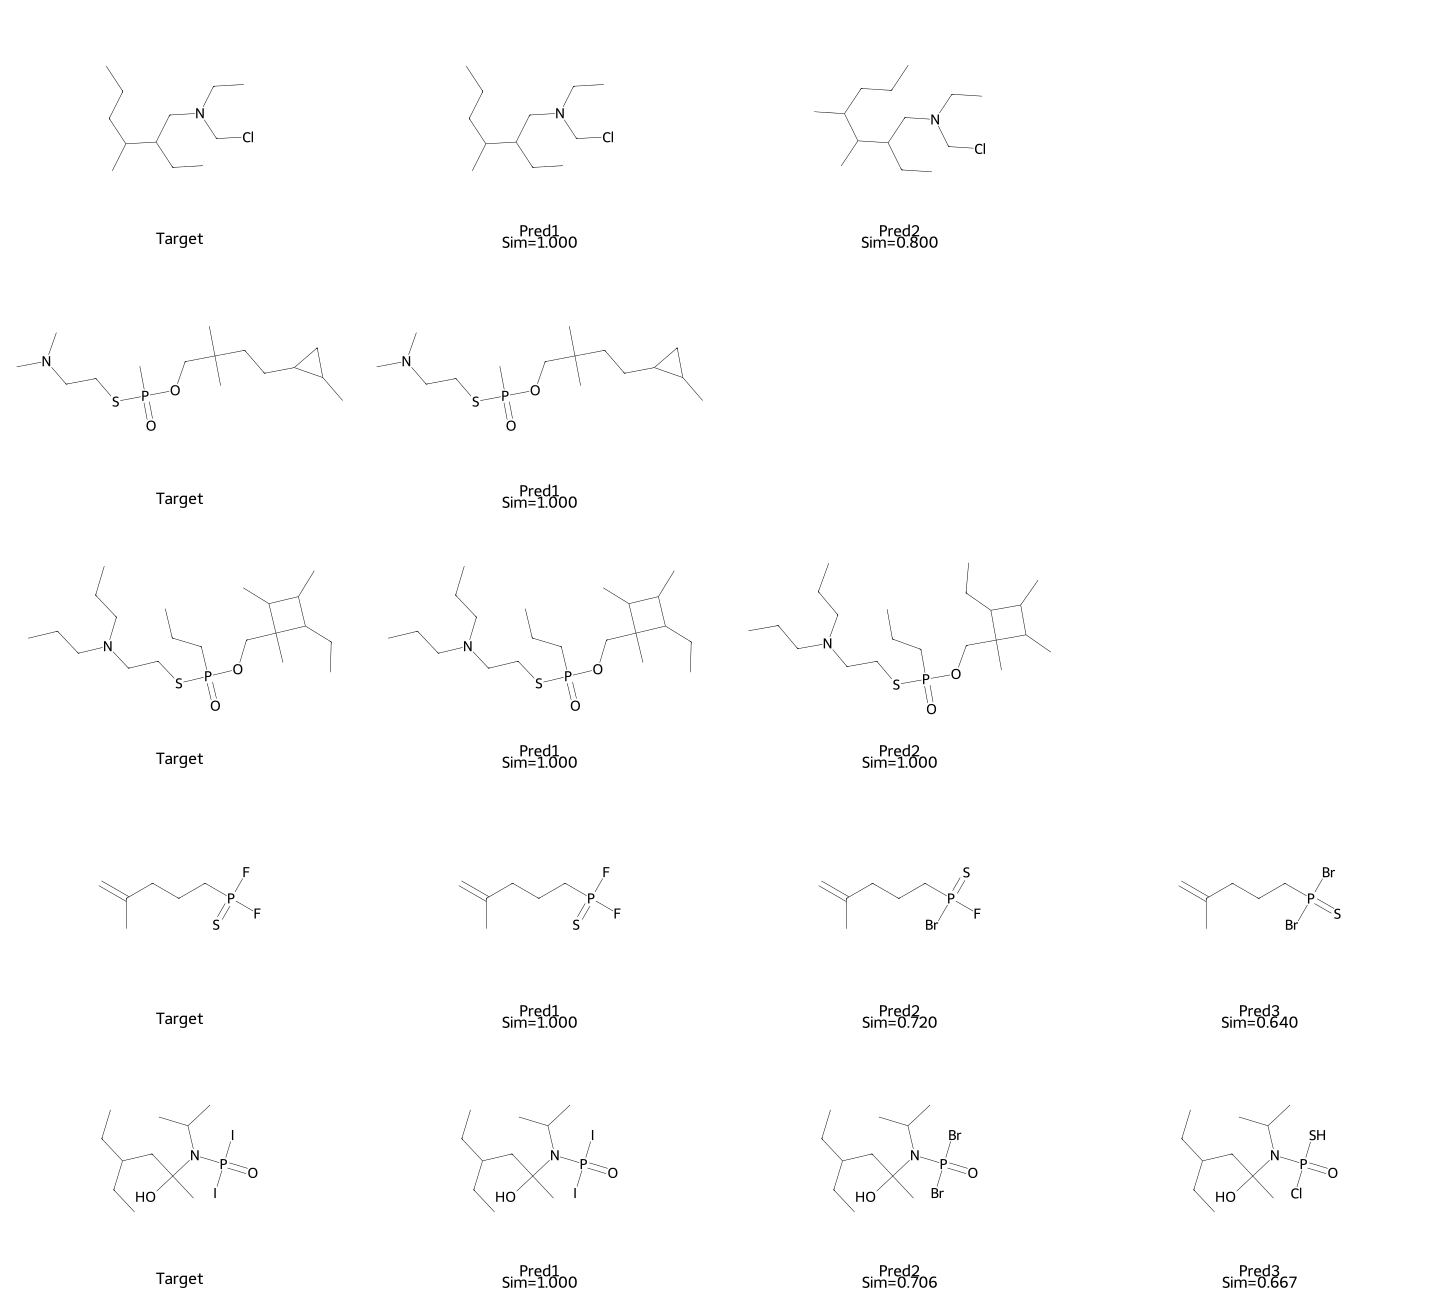

saved: D:\code\NMR_MS\output\fail_examples.png


[01:11:43] Explicit valence for atom # 9 P, 6, is greater than permitted
[01:11:43] SMILES Parse Error: unclosed ring for input: 'CCCPP(=O)(OOCCCN(CCC)OCCC)N1CCCCCC(F)CC'


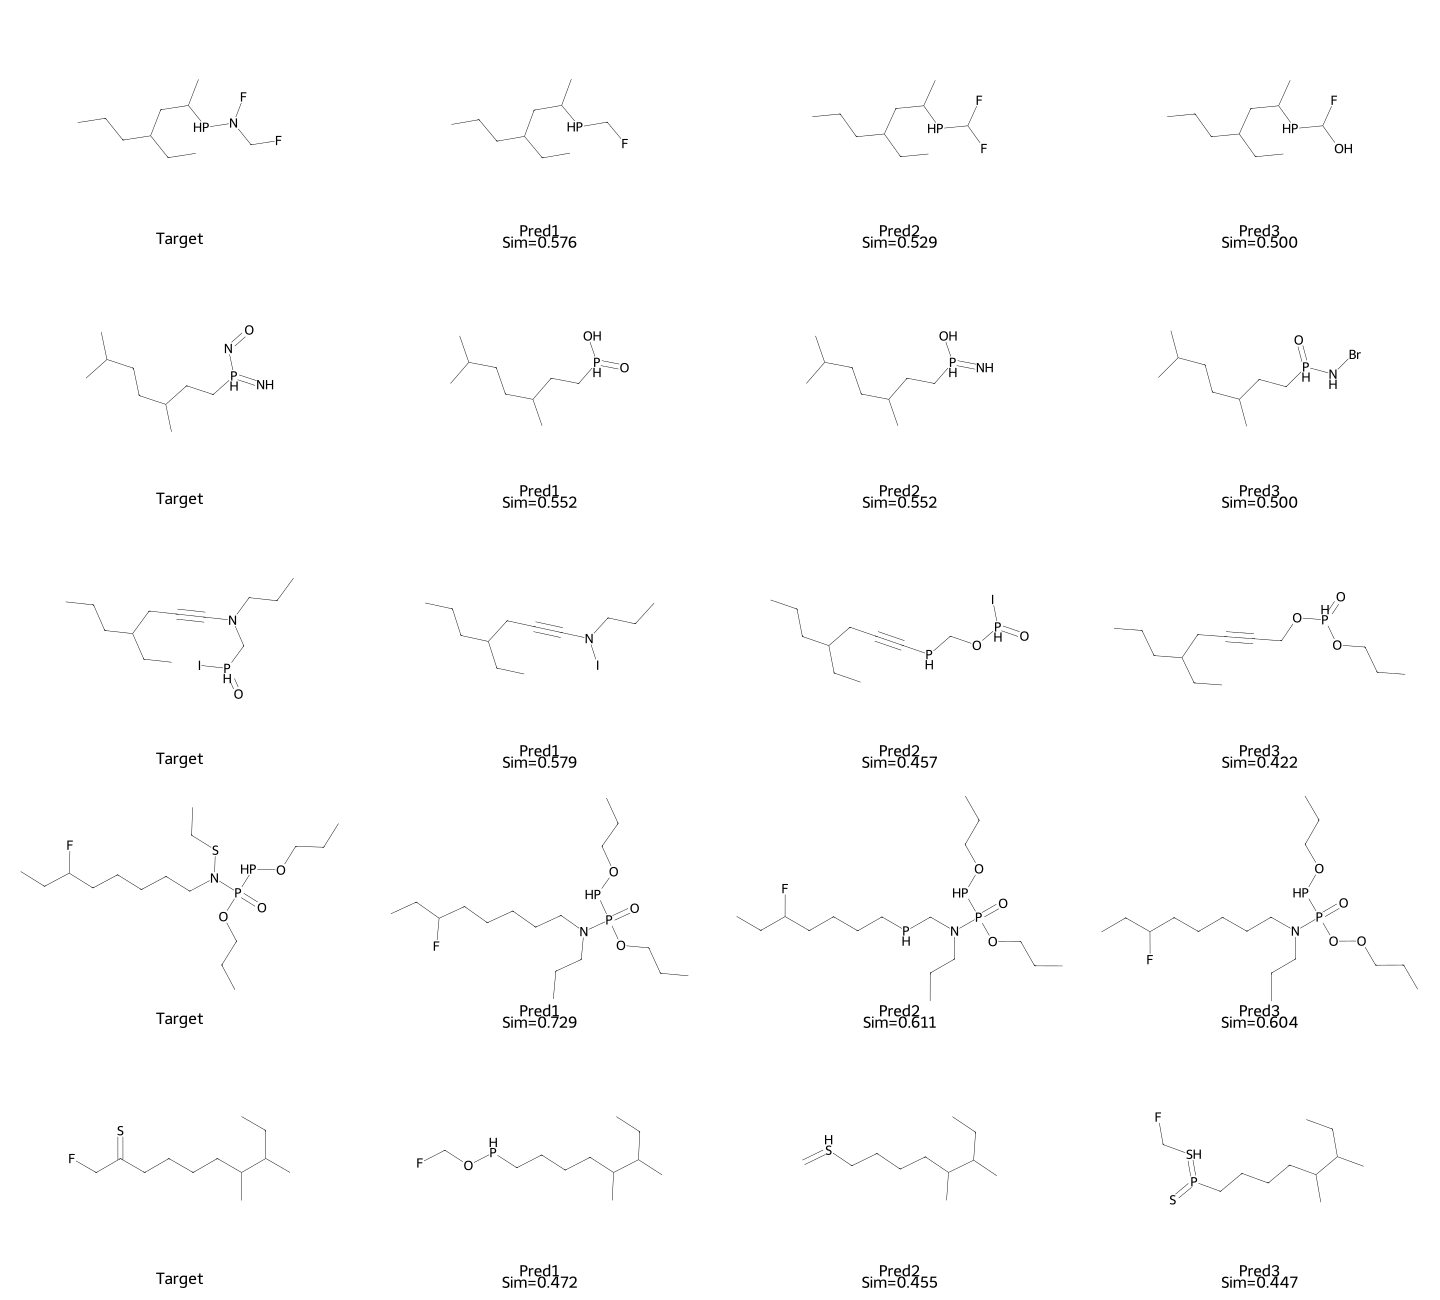

saved: D:\code\NMR_MS\output\examples_smiles_grid.txt


In [5]:
def build_row_mols_and_captions(row: pd.Series) -> Tuple[List[Chem.Mol], List[str]]:
    target = str(row['target_smiles'])
    preds = [str(row[c]) for c in pred_cols]

    top = best_topk_preds_by_similarity(target, preds, k=N_PRED_PER_ROW)

    mols: List[Chem.Mol] = []
    caps: List[str] = []

    t_mol = mol_from_smiles(target)
    if t_mol is None:
        # 如果target解析失败，用空分子占位
        t_mol = Chem.MolFromSmiles('')
    mols.append(t_mol)
    # 目标分子下面只写 Target
    caps.append("Target")

    for i, (smi, sim) in enumerate(top, start=1):
        m = mol_from_smiles(smi)
        if m is None:
            m = Chem.MolFromSmiles('')
        mols.append(m)
        # 推理分子：Predn + 相似度（字体在drawer里调大）
        caps.append(f"Pred{i}\nSim={sim:.3f}")

    # 保证每行固定列数（Target + N_PRED_PER_ROW）
    while len(mols) < 1 + N_PRED_PER_ROW:
        mols.append(Chem.MolFromSmiles(''))
        caps.append('')

    return mols, caps


def _safe_setattr(obj, name: str, value) -> bool:
    """跨 RDKit 版本安全设置 drawOptions 字段。"""
    if hasattr(obj, name):
        try:
            setattr(obj, name, value)
            return True
        except Exception:
            return False
    return False


def apply_acs_1996_style_params(opts) -> None:
    """按你提供的参数设置 RDKit MolDrawOptions（尽量兼容不同版本字段/方法）。"""
    # ===== ACS风格参数 =====
    _safe_setattr(opts, "bondLineWidth", 1.2)
    _safe_setattr(opts, "fixedBondLength", 30)
    _safe_setattr(opts, "multipleBondOffset", 0.18)

    # 注意：不同RDKit版本 baseFontSize 可能不存在；尽量设置 atomLabelFontSize
    _safe_setattr(opts, "baseFontSize", 0.7)
    _safe_setattr(opts, "atomLabelFontSize", 14)

    _safe_setattr(opts, "padding", 0.05)

    # useBWAtomPalette 在部分版本是方法，在部分版本是 bool 属性
    try:
        if hasattr(opts, "useBWAtomPalette") and callable(getattr(opts, "useBWAtomPalette")):
            opts.useBWAtomPalette()
        else:
            _safe_setattr(opts, "useBWAtomPalette", True)
    except Exception:
        _safe_setattr(opts, "useBWAtomPalette", True)

    _safe_setattr(opts, "explicitMethyl", False)
    _safe_setattr(opts, "additionalAtomLabelPadding", 0.02)
    # =====================


def _grid_to_png_bytes(
    mols: List[Chem.Mol],
    legends: List[str],
    mols_per_row: int,
    sub_img_size=(360, 260),
    padding_px: int = 12,
    bg_color=(1, 1, 1),
    use_cairo: bool = True,
    ) -> bytes:
    """输出PNG字节。默认走 MolDraw2DCairo（更接近印刷稿风格）。"""
    if not use_cairo:
        out = Draw.MolsToGridImage(
            mols,
            molsPerRow=mols_per_row,
            subImgSize=sub_img_size,
            legends=legends,
            useSVG=False,
            returnPNG=True,
        )
        if isinstance(out, (bytes, bytearray, memoryview)):
            return bytes(out)
        raise TypeError("MolsToGridImage(returnPNG=True) 未返回bytes，建议use_cairo=True")

    n_cols = mols_per_row
    n_rows = int(np.ceil(len(mols) / n_cols))
    w = sub_img_size[0] * n_cols
    h = sub_img_size[1] * n_rows
    drawer = rdMolDraw2D.MolDraw2DCairo(w, h, sub_img_size[0], sub_img_size[1])
    opts = drawer.drawOptions()

    # 背景色
    try:
        opts.clearBackground = False
        opts.backgroundColour = bg_color
    except Exception:
        pass

    # 如果你仍然想用 padding_px 控制留白，这里转换成相对 padding 并覆盖 opts.padding
    rel_padding = float(padding_px) / float(min(sub_img_size)) if min(sub_img_size) else 0.05
    rel_padding = max(0.02, min(rel_padding, 0.25))

    apply_acs_1996_style_params(opts)
    # 以“像素留白”为准的话，覆盖 ACS 默认 padding=0.05
    _safe_setattr(opts, "padding", rel_padding)

    # 可选：让网格更一致（字段不一定存在）
    _safe_setattr(opts, "drawMolsSameScale", True)
    _safe_setattr(opts, "scaleBondWidth", True)

    drawer.DrawMolecules(mols, legends=legends)
    drawer.FinishDrawing()
    return drawer.GetDrawingText()


def _smiles_or_blank(m: Optional[Chem.Mol]) -> str:
    if m is None:
        return ""
    try:
        # 对网格占位空mol，MolToSmiles 会返回空串
        return Chem.MolToSmiles(m)
    except Exception:
        return ""


def draw_examples_grid(examples: pd.DataFrame, title: str, out_png: str):
    """生成一张大图：每行是一个样例，每列是 Target + top3 preds。"""
    all_mols: List[Chem.Mol] = []
    all_caps: List[str] = []
    for _, r in examples.iterrows():
        mols, caps = build_row_mols_and_captions(r)
        all_mols.extend(mols)
        all_caps.extend(caps)

    n_cols = 1 + N_PRED_PER_ROW

    png_bytes = _grid_to_png_bytes(
        all_mols,
        all_caps,
        mols_per_row=n_cols,
        sub_img_size=(360, 260),
        padding_px=12,
        use_cairo=True,
    )

    Path(out_png).write_bytes(png_bytes)
    print('saved:', Path(out_png).resolve())

    try:
        from IPython.display import Image, display
        display(Image(filename=out_png))
    except Exception:
        pass

    # 返回每个格子的SMILES（按图片顺序：每行4个，共5行）
    smiles_grid = [_smiles_or_blank(m) for m in all_mols]
    return smiles_grid


def _format_smiles_block(smiles_flat: List[str], n_rows: int, n_cols: int) -> str:
    """把一维列表按行列格式化成文本（每行4个，用TAB分隔，方便和图片对齐看）。"""
    lines: List[str] = []
    for r in range(n_rows):
        row = smiles_flat[r * n_cols:(r + 1) * n_cols]
        if len(row) < n_cols:
            row = row + [""] * (n_cols - len(row))
        lines.append("\t".join(row))
    return "\n".join(lines)


def save_smiles_txt(
    fail_smiles_flat: List[str],
    success_smiles_flat: List[str],
    out_txt: str,
    n_rows: int,
    n_cols: int,
    ) -> None:
    txt_lines: List[str] = []
    txt_lines.append("# Fail (hit_rank == 0)")
    txt_lines.append(_format_smiles_block(fail_smiles_flat, n_rows=n_rows, n_cols=n_cols))
    txt_lines.append("")
    txt_lines.append("# Success (hit_rank != 0)")
    txt_lines.append(_format_smiles_block(success_smiles_flat, n_rows=n_rows, n_cols=n_cols))
    txt = "\n".join(txt_lines) + "\n"
    Path(out_txt).write_text(txt, encoding="utf-8")
    print('saved:', Path(out_txt).resolve())


success_smiles_flat = draw_examples_grid(success_examples, title='Inference success examples (random 5)', out_png='success_examples.png')
fail_smiles_flat = draw_examples_grid(fail_examples, title='Inference failed examples (random 5; hit_rank=0)', out_png='fail_examples.png')

# 同目录下写出一个对照txt：两段（失败在前、成功在后），每段5行×4列
save_smiles_txt(
    fail_smiles_flat=fail_smiles_flat,
    success_smiles_flat=success_smiles_flat,
    out_txt='examples_smiles_grid.txt',
    n_rows=N_ROWS_PER_FIG,
    n_cols=1 + N_PRED_PER_ROW,
 )

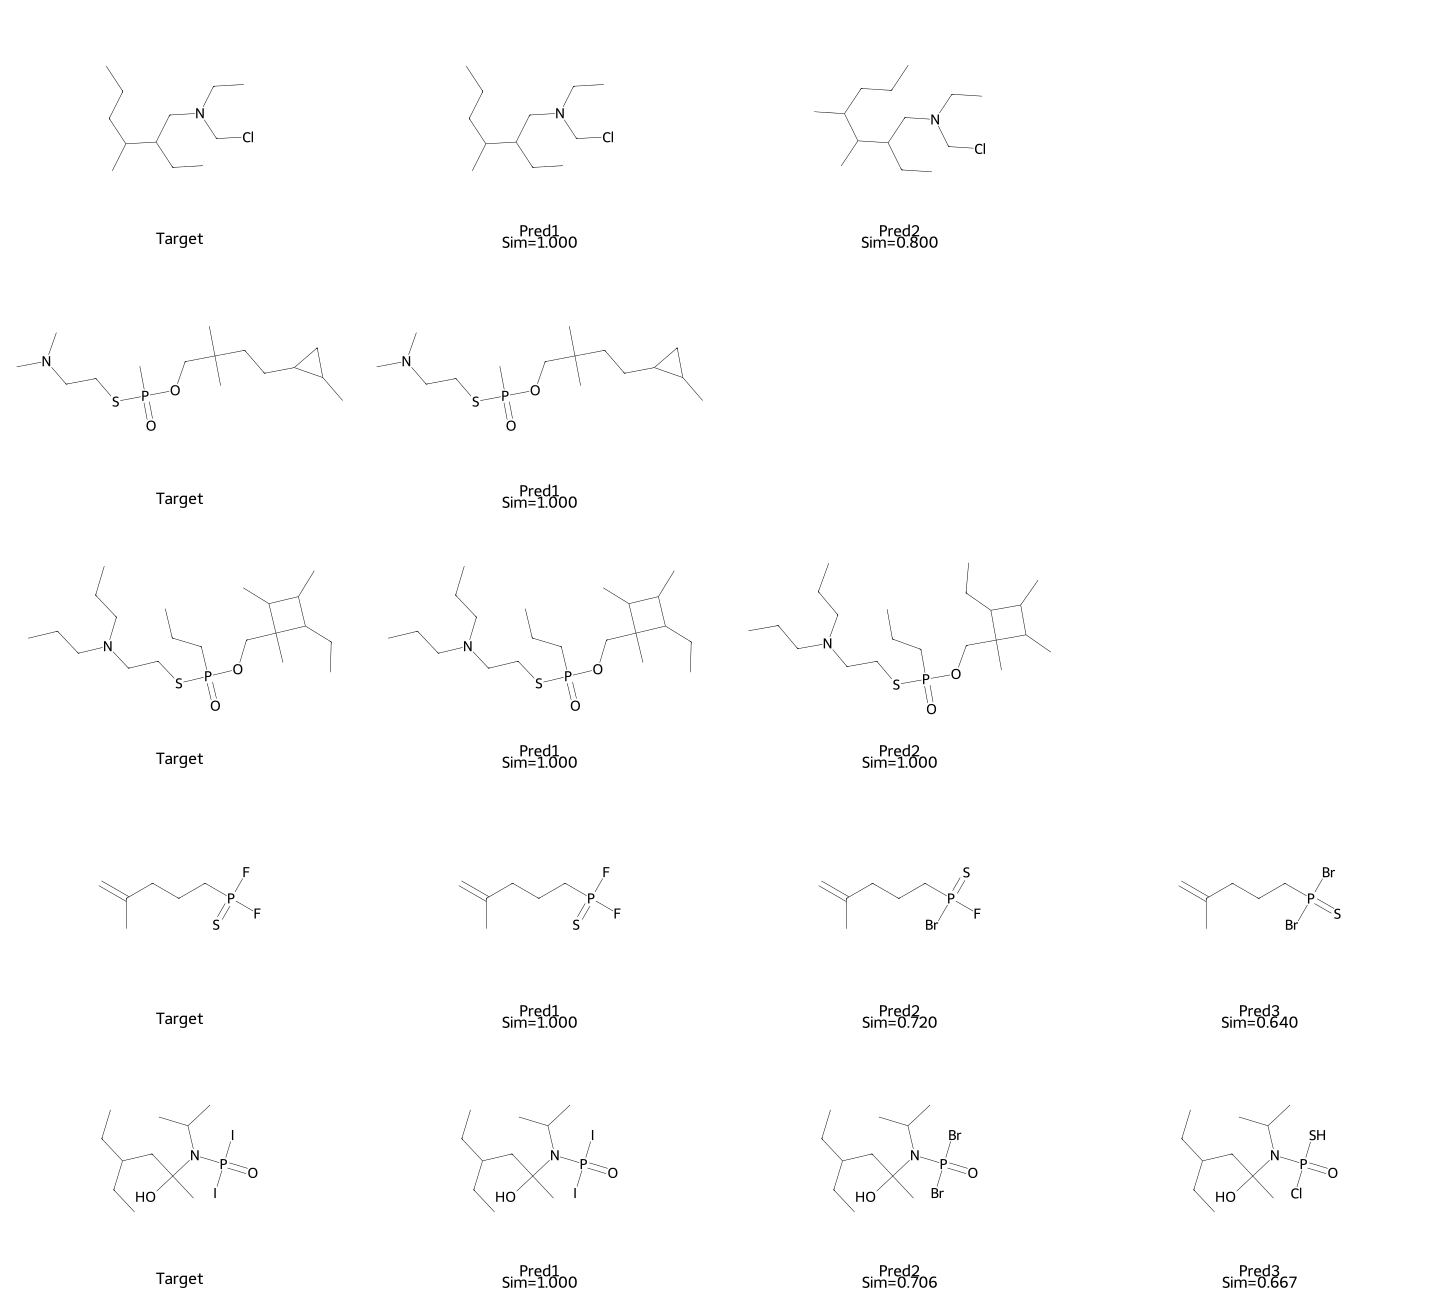

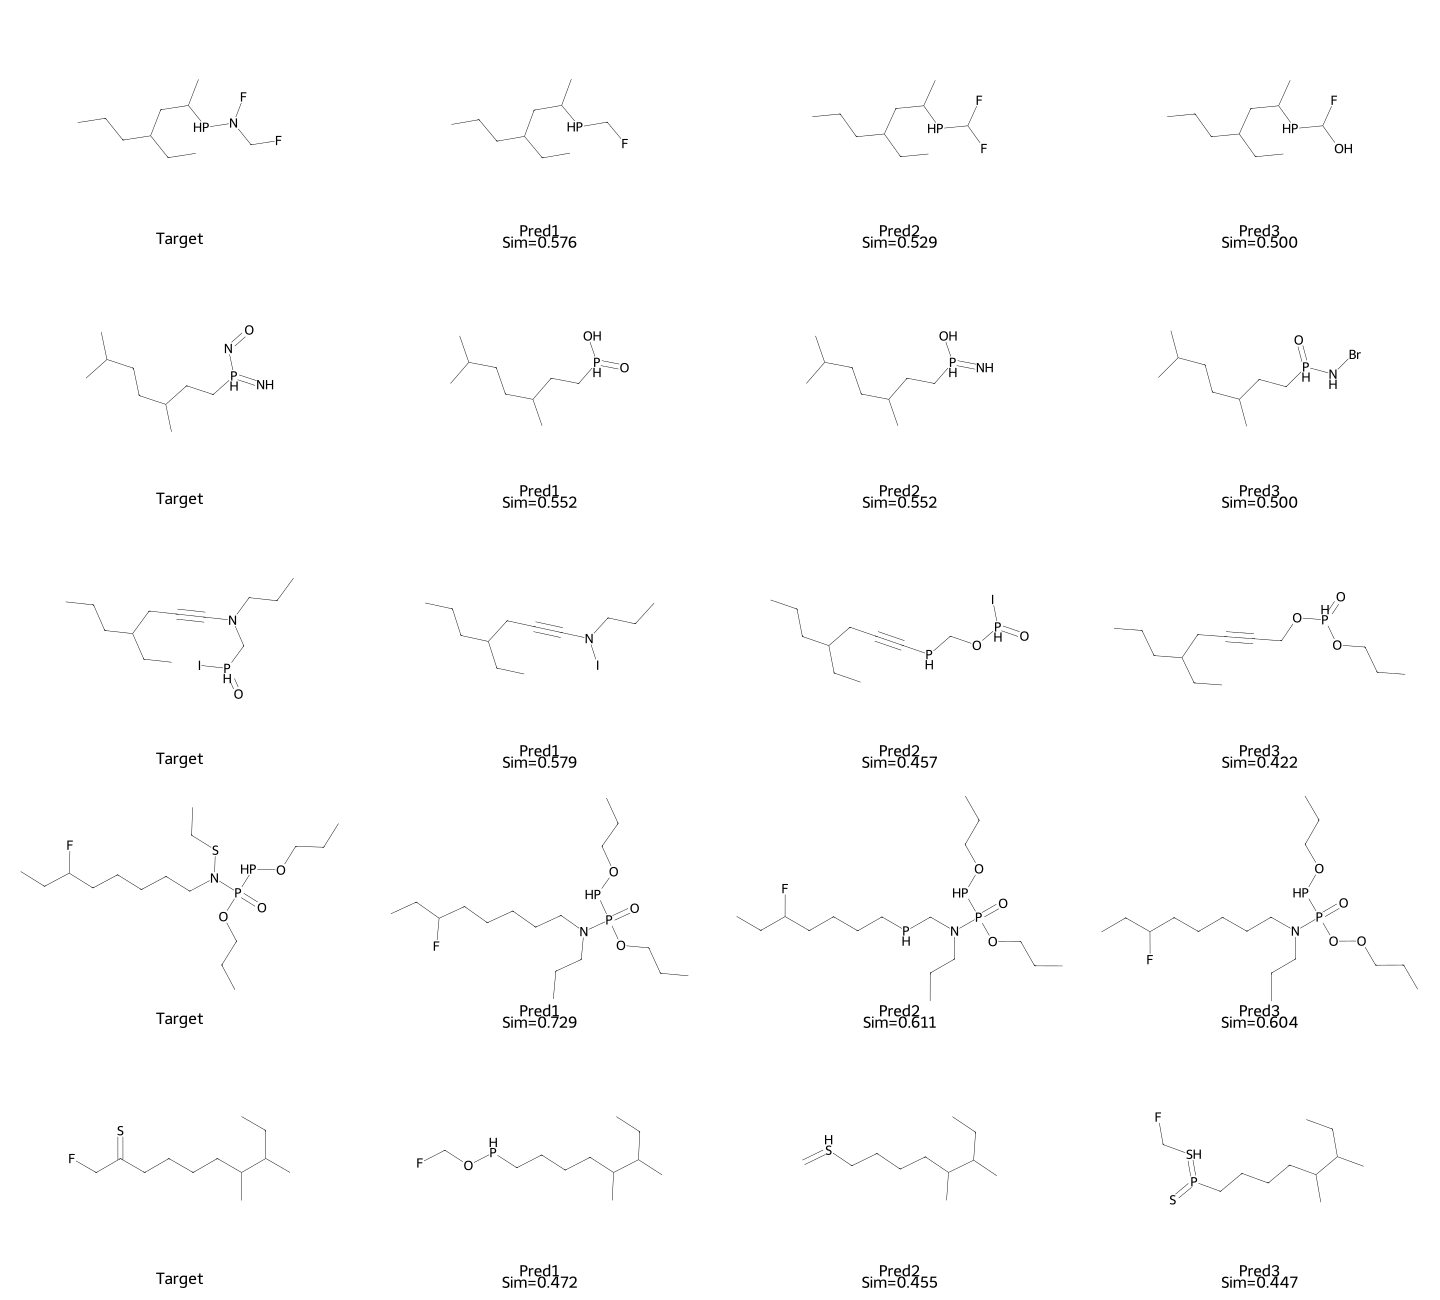

In [6]:
# 可视化：直接在notebook里显示输出图片（可选）
from PIL import Image

for p in ['success_examples.png', 'fail_examples.png']:
    if Path(p).exists():
        display(Image.open(p))